<a href="https://colab.research.google.com/github/asudekaqlan/AI-Based-Carbon-Footprint-Predictor/blob/main/energy_carbon_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# 1. Veri setlerini okuyalım
train_df = pd.read_csv('train_energy_data.csv')
test_df = pd.read_csv('test_energy_data.csv')

# 2. Matematiksel Dokunuş: Enerji Tüketiminden Karbon Ayak İzi (CO2) Hesabı
# Emisyon Faktörü = 0.475 kg CO2 / kWh
EMISSION_FACTOR = 0.475

train_df['Carbon_Footprint_kg'] = (
    train_df['Energy Consumption'] * EMISSION_FACTOR
)
test_df['Carbon_Footprint_kg'] = (
    test_df['Energy Consumption'] * EMISSION_FACTOR
)

print('--- Eğitim Verisi İlk 5 Satır ---')
print(train_df.head())

--- Eğitim Verisi İlk 5 Satır ---
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential            7063                   76               10   
1    Commercial           44372                   66               45   
2    Industrial           19255                   37               17   
3   Residential           13265                   14               41   
4    Commercial           13375                   26               18   

   Average Temperature Day of Week  Energy Consumption  Carbon_Footprint_kg  
0                29.84     Weekday             2713.95           1289.12625  
1                16.72     Weekday             5744.99           2728.87025  
2                14.30     Weekend             4101.24           1948.08900  
3                32.82     Weekday             3009.14           1429.34150  
4                11.92     Weekday             3279.17           1557.60575  


In [2]:
# Metinsel ifadeleri sayısal matrislere çevirelim (One-Hot Encoding)
train_encoded = pd.get_dummies(
    train_df, columns=['Building Type', 'Day of Week'], drop_first=True
)
test_encoded = pd.get_dummies(
    test_df, columns=['Building Type', 'Day of Week'], drop_first=True
)

# Girdileri (X) ve Hedef Değişkenimizi (y) ayıralım
# Hedef değişkenimiz: Energy Consumption
X_train = train_encoded.drop(
    columns=['Energy Consumption', 'Carbon_Footprint_kg']
)
y_train = train_encoded['Energy Consumption']

X_test = test_encoded.drop(
    columns=['Energy Consumption', 'Carbon_Footprint_kg']
)
y_test = test_encoded['Energy Consumption']

print('Modele girecek öznitelikler (Features):')
print(X_train.columns.tolist())

Modele girecek öznitelikler (Features):
['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Building Type_Industrial', 'Building Type_Residential', 'Day of Week_Weekend']


In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Tüm verileri sayısal (float) formata dönüştürelim
X_train_vif = X_train.astype(float)

# 2. VIF Hesabı
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_train_vif.values, i)
    for i in range(X_train_vif.shape[1])
]

print('--- Variance Inflation Factor (VIF) Analizi ---')
print(vif_data)

--- Variance Inflation Factor (VIF) Analizi ---
                     Feature       VIF
0             Square Footage  3.730700
1        Number of Occupants  3.416144
2            Appliances Used  3.545084
3        Average Temperature  6.188990
4   Building Type_Industrial  1.869760
5  Building Type_Residential  1.929905
6        Day of Week_Weekend  1.885316


In [5]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelleri Tanımlayalım
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (L2)': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

results = []

# Modelleri Eğitip Test Edelim
for name, model in models.items():
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)

  # Hata Metrikleri
  r2 = r2_score(y_test, predictions)
  rmse = np.sqrt(mean_squared_error(y_test, predictions))
  mae = mean_absolute_error(y_test, predictions)

  results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

results_df = pd.DataFrame(results)
print('--- MODEL PERFORMANS KARŞILAŞTIRMASI ---')
print(results_df)

--- MODEL PERFORMANS KARŞILAŞTIRMASI ---
                   Model  R2 Score        RMSE        MAE
0      Linear Regression  1.000000    0.014197   0.012162
1  Ridge Regression (L2)  0.999998    1.296130   1.138430
2          Random Forest  0.979185  119.515396  94.236204


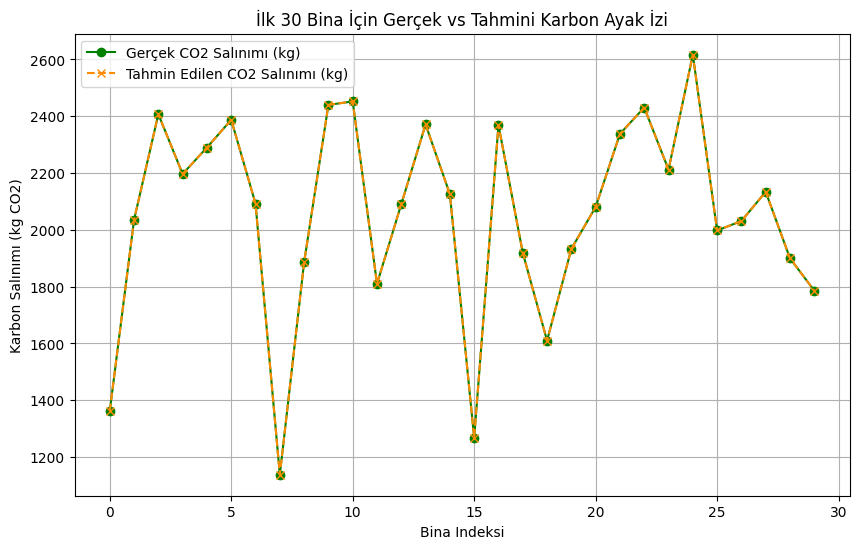

In [6]:
# En başarılı modeli seçip test verisinde Karbon Tahmini yapalım
best_model = LinearRegression()
best_model.fit(X_train, y_train)

# Enerji Tüketim Tahmini
predicted_energy = best_model.predict(X_test)

# Karbon Ayak İzi Tahmini (kg CO2)
predicted_carbon = predicted_energy * EMISSION_FACTOR
actual_carbon = y_test * EMISSION_FACTOR

# Tahmin vs Gerçek Karbon Salınımı Grafiği
plt.figure(figsize=(10, 6))
plt.plot(
    actual_carbon.values[:30],
    label='Gerçek CO2 Salınımı (kg)',
    marker='o',
    color='green',
)
plt.plot(
    predicted_carbon[:30],
    label='Tahmin Edilen CO2 Salınımı (kg)',
    marker='x',
    linestyle='--',
    color='darkorange',
)
plt.title('İlk 30 Bina İçin Gerçek vs Tahmini Karbon Ayak İzi')
plt.xlabel('Bina Indeksi')
plt.ylabel('Karbon Salınımı (kg CO2)')
plt.legend()
plt.grid(True)
plt.show()